# Bayesian Inference for Mass-Action Kinetics Model

Based on inference_pymc.py by Nathaniel Linden (UCSD MAE) - 2024

Edited by Annette Thompson (CU Boulder) - 2026

## Setup Environment

In [1]:
# Set XLA flags for multi-threading
import os
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=4"

## Import Libraries

In [2]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import diffrax as dfrx
import equinox as eqx
import pymc as pm
from pytensor.link.jax.dispatch import jax_funcify
import arviz as az
import nutpie

import json

from utils import *

# Import the reaction model builder
from reaction_model_builder import build_ode_system_from_reactions

# Tell JAX to use 64-bit floats
jax.config.update("jax_enable_x64", True)

print(f"JAX version: {jax.__version__}")
print(f"PyMC version: {pm.__version__}")
print(f"Number of JAX devices: {jax.device_count()}")

JAX version: 0.7.0
PyMC version: 5.27.1
Number of JAX devices: 4


## Set Parameters

In [3]:
# Model and inference parameters
reactions_file = "./reactions_MA.json"
solver_params_file = "./solver_params.json"
data_file = "./Data/Duggleby_Clarke_1991_Fig2.csv"
savedir = "./MA_Results"

# Create save directory if it doesn't exist
if not os.path.isdir(savedir):
    os.makedirs(savedir)
    print(f"Created directory: {savedir}")
else:
    print(f"Save directory exists: {savedir}")

print(f"Reaction file: {reactions_file}")
print(f"Solver parameters file: {solver_params_file}")
print(f"Save directory: {savedir}")

Save directory exists: ./MA_Results
Reaction file: ./reactions_MA.json
Solver parameters file: ./solver_params.json
Save directory: ./MA_Results


## Load Model and Model Information

In [4]:
# Load solver parameters and reactions
with open(solver_params_file, 'r') as file:
    solver_params = json.load(file)

# Build ODE system from reactions
ode_system, species_names, param_names, param_values = build_ode_system_from_reactions(reactions_file)

# Extract unknown parameters from the new format
unknown_params = [p['param_name'] for p in solver_params['unknown_kinetic_params']]

print(f"Species names: {species_names}")
print(f"Parameter names: {param_names}")
print(f"Unknown parameters: {unknown_params}")
print(f"Parameter nominal values: {param_values}")

Species names: ['S', 'E', 'ES', 'P']
Parameter names: ['k_f', 'k_r', 'k_cat']
Unknown parameters: ['k_f', 'k_r', 'k_cat']
Parameter nominal values: {'k_f': 0.1, 'k_r': 0.025, 'k_cat': 1.0}


## Load Data

In [5]:
# Load the data
dat = pd.read_csv(data_file)
times = dat['time'].to_numpy()
data = dat['conc (mM)'].to_numpy()

# Assume data std is 5% of the mean
data_std = 0.05 * np.mean(data)

print(f"Data loaded from: {data_file}")
print(f"Number of time points: {len(times)}")
print(f"Time range: {times[0]:.2f} to {times[-1]:.2f}")
print(f"Data mean: {np.mean(data):.4f}, std: {data_std:.4f}")

# Display first few data points
display(dat.head())

Data loaded from: ./Data/Duggleby_Clarke_1991_Fig2.csv
Number of time points: 11
Time range: 0.00 to 23.33
Data mean: 0.3367, std: 0.0168


,time,conc (mM)
0,0.000000,0.000000
1,2.333333,0.075862
2,4.666667,0.155172
3,7.000000,0.227586
4,9.350000,0.293103


## Define Simulator Function

In [6]:
# ODE solver setup

# Extract ODE solver parameters - automatically set variables from config
ode_solver_config = solver_params.get('ODE_solver', {})
for key, value in ode_solver_config.items():
    if value is not None:
        globals()[key] = value

ode_controller_config = solver_params.get('ODE_stepsize_controller', {})
for key, value in ode_controller_config.items():
    if value is not None:
        globals()[key] = value

solver = eval('dfrx.' + solver_name + '()')
stepsize_controller = dfrx.PIDController(**{k: v for k, v in ode_controller_config.items()})
t0 = 0.0
t1 = times[-1]
saveat = dfrx.SaveAt(ts=times)

# Build y0 with all species, defaulting to 0 if not specified in solver_params
provided_init_conds = solver_params.get("init_conds", {})
y0 = []
for species in species_names:
    y0.append(provided_init_conds.get(species, 0.0))
y0_jax = jnp.array(y0)

# Create the ODE term with the dynamically built system
rhs = dfrx.ODETerm(ode_system)

def simulator(params):
    """Solve ODE and compute product/(substrate + product) ratio"""
    # Solve model
    sol = dfrx.diffeqsolve(
        rhs, solver, t0=t0, t1=t1, dt0=dt0, 
        y0=y0_jax, args=params, saveat=saveat,
        stepsize_controller=stepsize_controller,
        max_steps=max_steps, throw=True 
    )
    sol = jnp.squeeze(sol.ys)

    # For MA kinetics: compute P / (S + ES + P) (TODO: remove hardcoding of data-file basedcalculations)
    prod_idx = species_names.index('P')
    sub_idx = species_names.index('S')
    es_idx = species_names.index('ES')

    total = sol[:, sub_idx] + sol[:, es_idx] + sol[:, prod_idx]
    result = sol[:, prod_idx] / total

    return result.reshape(1, len(result))

print("Simulator function defined")

Simulator function defined


## Create PyTensor Ops for PyMC Integration

In [7]:
# Construct PyTensor Op for simulator
def sol_op_jax(*params):
    return simulator(params)

sol_op_jax_jitted = eqx.filter_jit(sol_op_jax)

def vjp_sol_op_jax(gz, *params):
    _, vjp_fn = jax.vjp(sol_op_jax, *params)
    return vjp_fn(gz)

vjp_sol_op_jax_jitted = eqx.filter_jit(vjp_sol_op_jax)

vjp_sol_op = VJPSolOp(vjp_sol_op_jax_jitted)
sol_op = SolOp(sol_op_jax_jitted, vjp_sol_op)

# Register the ops with PyTensor
@jax_funcify.register(SolOp)
def sol_op_jax_funcify(op, **kwargs):
    return sol_op_jax

@jax_funcify.register(VJPSolOp)
def vjp_sol_op_jax_funcify(op, **kwargs):
    return vjp_sol_op_jax

print("PyTensor operations registered")

PyTensor operations registered


## Build PyMC Model

In [8]:

prior_config = solver_params.get('prior_sampling', {})
for key, value in prior_config.items():
    if value is not None:
        globals()[key] = value

# Build prior dictionary from solver_params
prior_dict = {}
for param_spec in solver_params['unknown_kinetic_params']:
    param_name = param_spec['param_name']
    prior_params = param_spec['prior_dist_params']
    
    dist = eval('pz.'+prior_params['distribution']+'()')
    result = pz.maxent(dist, prior_params['lower'], prior_params['upper'], prior_params.get('mass', 0.95), plot=False)
    prior_dict[param_name] = f'pm.{result.__class__.__name__}("{param_name}",{",".join([f"{float(v)}" for v in result.params])})'

print("Prior parameters:")
for param, prior in prior_dict.items():
    print(f"  {param}: {prior}")

# Construct the PyMC model
with pm.Model() as pm_model:
    priors = {}
    for param, prior in prior_dict.items():
        # create PyMC variables for each parameters in the model
        priors[param] = eval(prior)

    # predict response
    prediction = pm.Deterministic('prediction', sol_op(*[priors[param] for param in prior_dict.keys()]))
    
    # assume a normal model for the data
    # sigma specified by the data_sigma param to this function
    llike = pm.Normal("llike", mu=prediction, sigma=data_std, observed=data.reshape(1, len(data)))

print("\nPyMC model built successfully")

Prior parameters:
  k_f: pm.Gamma("k_f",3.1415056519068996,33.011518208023595)
  k_r: pm.Gamma("k_r",3.1402159569393238,132.01220845862787)
  k_cat: pm.Gamma("k_cat",3.1414139363574662,3.301091291545485)

PyMC model built successfully


## Sample from Prior

In [9]:
# Prior sampling
print("Sampling from prior...")
with pm_model:
    prior_pred = pm.sample_prior_predictive(draws=draws, random_seed=random_seed)

# Save prior samples
prior_file = os.path.join(savedir, 'MA_prior_samples_pm.nc')
if os.path.exists(prior_file):
    os.remove(prior_file)
    print(f"Removed existing file: {prior_file}")
prior_pred.to_netcdf(prior_file)
print(f"Prior samples saved to: {prior_file}")

Sampling from prior...


Sampling: [k_cat, k_f, k_r, llike]


Removed existing file: ./MA_Results/MA_prior_samples_pm.nc
Prior samples saved to: ./MA_Results/MA_prior_samples_pm.nc


## Run MCMC Sampling

In [10]:
posterior_config = solver_params.get('posterior_sampling', {})
for key, value in posterior_config.items():
    if value is not None:
        globals()[key] = value

# MCMC sampling
with pm_model:
    posterior = pm.sample(
        draws=draws, 
        tune=tune, 
        chains=chains, 
        cores=None if cores == "None" else int(cores), # None = all CPUs in system (up to 4)
        nuts_sampler=nuts_sampler,
        random_seed=random_seed
    )

    pm.compute_log_likelihood(posterior)

print("MCMC sampling completed!")

/opt/anaconda3/envs/Bayesian/lib/python3.13/site-packages/pytensor/link/numba/dispatch/basic.py:211: UserWarning: Numba will use object mode to run SolOp's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
/opt/anaconda3/envs/Bayesian/lib/python3.13/site-packages/pytensor/link/numba/dispatch/basic.py:211: UserWarning: Numba will use object mode to run VJPSolOp's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
/opt/anaconda3/envs/Bayesian/lib/python3.13/site-packages/pytensor/link/numba/dispatch/basic.py:211: UserWarning: Numba will use object mode to run SolOp's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,500,1,0.63,3
,500,0,0.61,7
,500,0,0.68,3
,500,0,0.61,3


Output()

MCMC sampling completed!


## Posterior Predictive Sampling

In [11]:
# Posterior predictive sampling
print(f"Running posterior predictive sampling...")
post_pred = pm.sample_posterior_predictive(posterior, model=pm_model)
print("Posterior predictive sampling completed!")

Sampling: [llike]


Output()

Running posterior predictive sampling...


Posterior predictive sampling completed!


## Save Results

In [12]:
# Combine all results
posterior.extend(prior_pred)
posterior.extend(post_pred)

# Save as netcdf file
results_file = os.path.join(savedir, 'MA_mcmc_samples_pm.nc')
if os.path.exists(results_file):
    os.remove(results_file)
    print(f"Removed existing file: {results_file}")
posterior.to_netcdf(results_file)

print(f"\nAll results saved to: {results_file}")
print(f"Completed inference")


All results saved to: ./MA_Results/MA_mcmc_samples_pm.nc
Completed inference


## Display Summary Statistics


=== MCMC Summary ===


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
k_f,0.042,0.002,0.040,0.046,0.000,0.000,278.0,280.0,1.02
k_r,0.025,0.014,0.005,0.049,0.001,0.001,469.0,462.0,1.00
k_cat,1.389,0.490,0.647,2.286,0.028,0.023,293.0,307.0,1.02



Trace plots generated


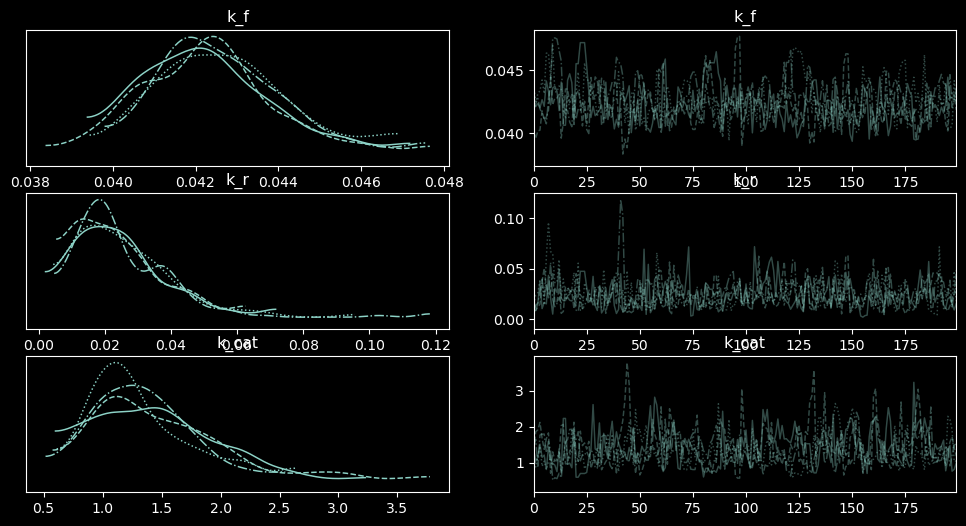

In [13]:
# Display summary
print("\n=== MCMC Summary ===")
summary = az.summary(posterior, var_names=unknown_params)
display(summary)

# Plot trace
az.plot_trace(posterior, var_names=unknown_params)
print("\nTrace plots generated")